# Laboratorio 3
**Dataset:** Flight Price Prediction 

## 1. Carga y Preprocesamiento de Datos
Utilizamos Pandas para cargar el dataset y convertimos las variables categóricas (aerolínea, ciudad, clase) en columnas numéricas. Eliminamos la columna `flight` ya que es un identificador único que no aporta a la predicción. Dividimos en 80% entrenamiento y 20% prueba, y finalmente normalizamos.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Carga de datos
df = pd.read_csv('Clean_Dataset.csv')

# Limpieza básica
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
df = df.drop('flight', axis=1) # Es un ID, no nos sirve para predecir

# 2. Convertir categóricas a numéricas
df = pd.get_dummies(df, drop_first=True)
df = df.astype(float)

# Separar X e y
X_pandas = df.drop('price', axis=1)
y_pandas = df['price']

X = X_pandas.values
y = y_pandas.values
m = len(y)

print(f"Ejemplos (m): {m}")
print(f"Características (n) tras el preprocesamiento: {X.shape[1]}")

# 3. División 80/20
train_size = int(m * 0.8)
np.random.seed(42)
indices = np.random.permutation(m)
X, y = X[indices], y[indices]

X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

# 4. Normalización
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_train_norm, mu, sigma = featureNormalize(X_train)
X_test_norm = (X_test - mu) / sigma

# Agregar columna de unos (X0)
X_train_ready = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_ready = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

Ejemplos (m): 300153
Características (n) tras el preprocesamiento: 30


## 2. Regresión Lineal Multivariable
Implementamos el descenso por el gradiente clásico.

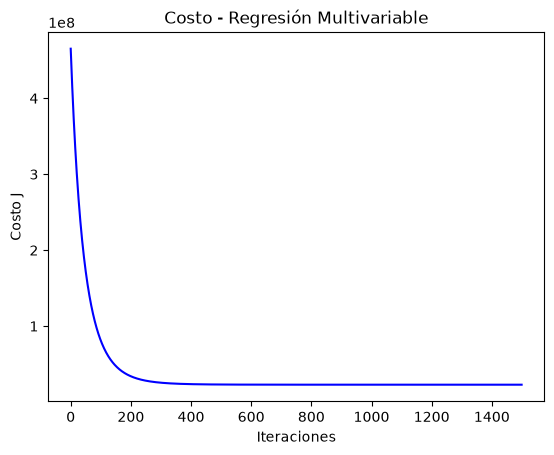

In [7]:
def computeCost(X, y, theta):
    m = len(y)
    return (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

def gradientDescent(X, y, theta, alpha, num_iters):
    m = len(y)
    theta = theta.copy()
    J_history = []
    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCost(X, y, theta))
    return theta, J_history

# Entrenamiento Multivariable
alpha = 0.01
num_iters = 1500
theta_multi = np.zeros(X_train_ready.shape[1])

theta_multi, J_history_multi = gradientDescent(X_train_ready, y_train, theta_multi, alpha, num_iters)

plt.plot(J_history_multi, color='blue')
plt.xlabel('Iteraciones')
plt.ylabel('Costo J')
plt.title('Costo - Regresión Multivariable')
plt.show()

## 3. Regresión Polinómica


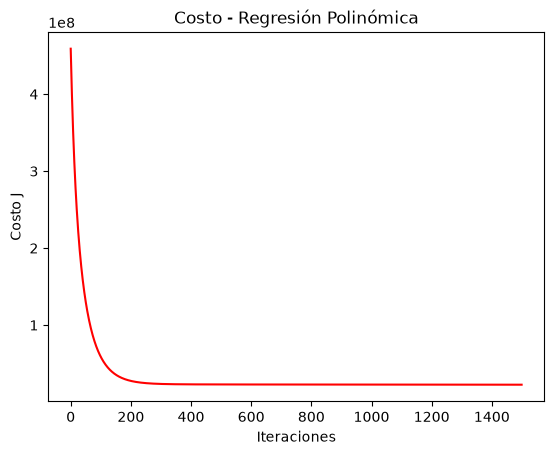

In [8]:
# 1. Generar características polinómicas (X y X^2) con los datos originales (sin normalizar)
X_train_poly_raw = np.concatenate([X_train, np.square(X_train)], axis=1)
X_test_poly_raw = np.concatenate([X_test, np.square(X_test)], axis=1)

# 2. Normalizar TODA la matriz polinómica nueva usando nuestra función
X_train_poly_norm, mu_poly, sigma_poly = featureNormalize(X_train_poly_raw)
X_test_poly_norm = (X_test_poly_raw - mu_poly) / sigma_poly

# 3. Agregar columna de unos (X0)
X_train_poly_ready = np.concatenate([np.ones((X_train_poly_norm.shape[0], 1)), X_train_poly_norm], axis=1)
X_test_poly_ready = np.concatenate([np.ones((X_test_poly_norm.shape[0], 1)), X_test_poly_norm], axis=1)

# 4. Entrenamiento Polinómico
alpha_poly = 0.01
theta_poly = np.zeros(X_train_poly_ready.shape[1])
theta_poly, J_history_poly = gradientDescent(X_train_poly_ready, y_train, theta_poly, alpha_poly, num_iters)

# Gráfica
plt.plot(J_history_poly, color='red')
plt.xlabel('Iteraciones')
plt.ylabel('Costo J')
plt.title('Costo - Regresión Polinómica')
plt.show()

## 4. Ecuación de la Normal

In [9]:
# Preparar datos sin normalizar para Ecuación Normal
X_train_normEq = np.concatenate([np.ones((X_train.shape[0], 1)), X_train], axis=1)
X_test_normEq = np.concatenate([np.ones((X_test.shape[0], 1)), X_test], axis=1)

def normalEqn(X, y):
    # theta = inv(X.T * X) * X.T * y
    return np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)

theta_normal = normalEqn(X_train_normEq, y_train)
print("Theta calculado por Ecuación de la Normal con éxito.")

Theta calculado por Ecuación de la Normal con éxito.


## 5. Validación: 100 Predicciones
Extraemos 100 ejemplos de nuestro conjunto de prueba (que el modelo no vio en el entrenamiento) y comparamos las predicciones de los tres modelos con los precios reales.

In [10]:
# Tomar 100 ejemplos de prueba
X_100_multi = X_test_ready[:100]
X_100_poly = X_test_poly_ready[:100]
X_100_normEq = X_test_normEq[:100]
y_100_real = y_test[:100]

# Predecir
pred_multi = np.dot(X_100_multi, theta_multi)
pred_poly = np.dot(X_100_poly, theta_poly)
pred_normal = np.dot(X_100_normEq, theta_normal)

# Mostrar una muestra de 10 comparaciones
print("Predicciones para los primeros 10 vuelos de prueba:\n")
for i in range(10):
    print(f"Real: {y_100_real[i]:.0f} | Multi: {pred_multi[i]:.0f} | Poly: {pred_poly[i]:.0f} | Normal: {pred_normal[i]:.0f}")

Predicciones para los primeros 10 vuelos de prueba:

Real: 23484 | Multi: 40231 | Poly: 40586 | Normal: 40227
Real: 3971 | Multi: 8846 | Poly: 8661 | Normal: 8794
Real: 3831 | Multi: 474 | Poly: 1110 | Normal: 555
Real: 11497 | Multi: 11679 | Poly: 11827 | Normal: 11666
Real: 57017 | Multi: 53604 | Poly: 53466 | Normal: 53659
Real: 78554 | Multi: 57156 | Poly: 57499 | Normal: 57117
Real: 4946 | Multi: 6611 | Poly: 6113 | Normal: 6651
Real: 8854 | Multi: -2027 | Poly: -2165 | Normal: -1949
Real: 81169 | Multi: 56612 | Poly: 56484 | Normal: 56633
Real: 50271 | Multi: 55781 | Poly: 55741 | Normal: 55794
